In [7]:
%pip install lightgbm xgboost catboost


Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
import pandas as pd
import joblib


from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from src.simulator_betting import *
from src.config import *
from src.utils import get_latest_file
pd.set_option("display.max_columns", None)

In [9]:

bets_df, summary = run_season_simulation(["2022-23", "2023-24"], exclude_future_seasons=True, 
                            min_ev=0.11,          
                            bankroll=1000, 
                            max_risk=0.02,         
                            prob_diff=0.05,        
                            odds_max=3,          
                            odds_min=1.15,           
                            ev_diff_min=0.10,      
                            streak_limit=10,        
                            bankroll_stop=0.2,     
                            skip_first_n=0, 
                            model_identifier="default"
                        )

# print("\n=== Résumé des paris ===")
# print(summary)
# print("\n=== Détails des paris ===")
# print(bets_df.head())


=== Simulation pour la saison 2022-23 ===
Chargement du modèle existant pour 2022-23 (default)
Modèle chargé depuis data/models/simulations/model_2022-23_default.joblib

Nombre de lignes fusionnées: 5196
Nombre de correspondances réussies: 2640
Nombre de correspondances échouées: 2556

IDs manquants TEAM_ID: []
IDs manquants OPP_TEAM_ID: []
------------------ Nombre de lignes supprimées pour cotes manquantes: 4 ------------------
  Match 1 placed : Pari sur boston celtics ! Mise: 20.00, GAGNÉ, Bankroll: 1012.60
  Match 2 ignoré : ev below min (0.030)
  Match 3 ignoré : ev below min (-0.157)
  Match 4 placed : Pari sur indiana pacers ! Mise: 20.25, PERDU, Bankroll: 992.35
  Match 5 ignoré : odds too high
  Match 6 ignoré : ev below min (0.082)
  Match 7 ignoré : ev below min (-0.124)
  Match 8 placed : Pari sur toronto raptors ! Mise: 19.85, GAGNÉ, Bankroll: 1005.45
  Match 9 placed : Pari sur memphis grizzlies ! Mise: 20.11, GAGNÉ, Bankroll: 1015.50
  Match 10 ignoré : odds too high
 

In [10]:
#save the bets DataFrame to a CSV file

os.makedirs(DATA_SIMULATIONS_DIR, exist_ok=True)
today = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")
bets_output_file = os.path.join(DATA_SIMULATIONS_DIR, f"bets_{today}.csv")

bets_df.to_csv(bets_output_file, index=False)

In [11]:
#test all possible combinations of parameters for the betting simulation and save the results

In [12]:
bets_df

,date,game_id,team,odds,prob,ev,stake,won,gain,bankroll,comment
0,2022-10-18,22200001.0,boston celtics,1.63,0.683993,0.114908,20.000000,1,12.600000,1012.600000,bet placed
1,2022-10-18,22200002.0,golden state warriors,1.28,0.804542,0.029813,0.000000,1,0.000000,1012.600000,ev below min (0.030)
2,2022-10-19,22200003.0,detroit pistons,1.61,0.523515,-0.157141,0.000000,1,0.000000,1012.600000,ev below min (-0.157)
3,2022-10-19,22200004.0,indiana pacers,2.06,0.574817,0.184123,20.252000,0,-20.252000,992.348000,bet placed
4,2022-10-19,22200005.0,houston rockets,4.25,0.236940,0.006996,0.000000,0,0.000000,992.348000,odds too high
...,...,...,...,...,...,...,...,...,...,...,...
2623,2024-04-17,52300111.0,chicago bulls,1.58,0.626701,-0.009812,0.000000,1,0.000000,364.698615,ev below min (-0.010)
2624,2024-04-16,52300121.0,new orleans pelicans,1.77,0.631887,0.118440,7.293972,0,-7.293972,357.404643,bet placed
2625,2024-04-16,52300131.0,sacramento kings,2.08,0.656667,0.365868,7.148093,1,7.719940,365.124583,bet placed
2626,2024-04-19,52300201.0,miami heat,1.66,0.684102,0.135609,7.302492,1,4.819644,369.944227,bet placed


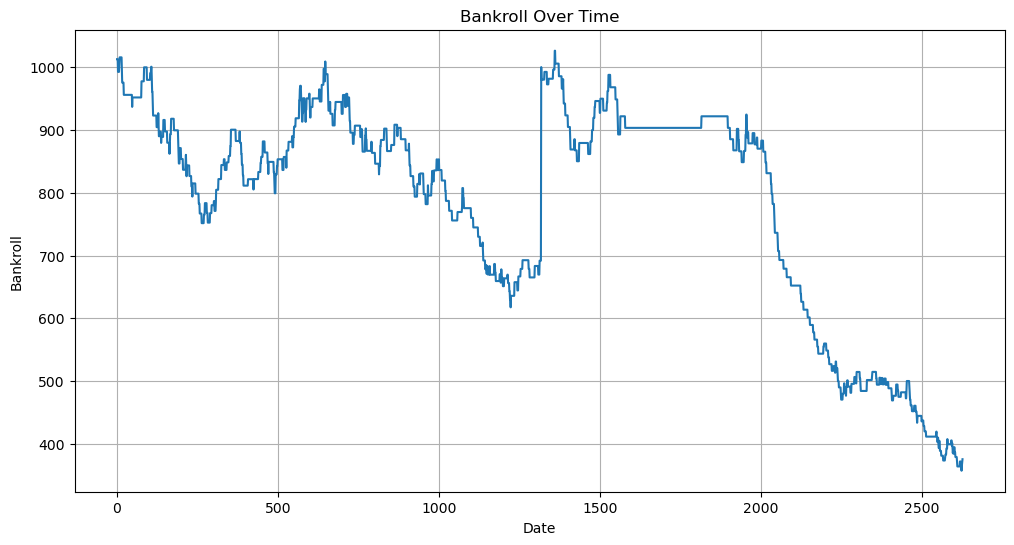

In [13]:
#plot bets_df

import matplotlib.pyplot as plt
bets_df['bankroll'].plot(kind='line', figsize=(12, 6), title='Bankroll Over Time')
plt.xlabel('Date')
plt.ylabel('Bankroll')
plt.grid()



